Датасет - https://www.kaggle.com/competitions/london-house-price-prediction-advanced-techniques

In [101]:
pip install XGBoost

Note: you may need to restart the kernel to use updated packages.


In [102]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
import torch
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer
import xgboost as xgb
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import mean_absolute_error

In [104]:
data = pd.read_csv('/kaggle/input/competitions/london-house-price-prediction-advanced-techniques/train.csv')

In [105]:
data

,ID,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,sale_month,sale_year,price
0,0,"38 Adelina Grove, London, E1 3AD",E1 3AD,England,E1,51.519406,-0.053261,NaN,3.0,80.0,1.0,Freehold,Semi-Detached House,C,1,1995,77000
1,1,"6 Cleveland Grove, London, E1 4XL",E1 4XL,England,E1,51.521261,-0.053384,2.0,4.0,110.0,1.0,Leasehold,Terrace Property,D,1,1995,89995
2,2,"65 Sanderstead Road, London, E10 7PW",E10 7PW,England,E10,51.569054,-0.034892,1.0,3.0,84.0,1.0,Freehold,Terrace Property,D,1,1995,59000
3,3,"5 Queenswood Gardens, London, E11 3SE",E11 3SE,England,E11,51.564212,0.026292,NaN,2.0,72.0,1.0,Leasehold,Purpose Built Flat,NaN,1,1995,51500
4,4,"12 Woodlands Road, London, E11 4RW",E11 4RW,England,E11,51.563430,0.006260,1.0,3.0,104.0,1.0,Freehold,Mid Terrace House,D,1,1995,63500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266320,266320,"Flat 5, 4 Acton Street, London, WC1X 9NA",WC1X 9NA,England,WC1X,51.528933,-0.116113,2.0,2.0,83.0,1.0,Leasehold,Flat/Maisonette,E,12,2023,800000
266321,266321,"7 Spring House, Margery Street, London, WC1X 0HT",WC1X 0HT,England,WC1X,51.527292,-0.112005,1.0,2.0,69.0,1.0,Leasehold,Converted Flat,C,12,2023,550000
266322,266322,"Flat 2, Goldsmith Court, Stukeley Street, Lond...",WC2B 5LF,England,WC2B,51.516084,-0.123581,1.0,2.0,50.0,1.0,Leasehold,Purpose Built Flat,C,12,2023,730000
266323,266323,"Unit 205, 25 Floral Street, London, WC2E 9DS",WC2E 9DS,England,WC2E,51.511861,-0.125419,2.0,2.0,130.0,1.0,Leasehold,Flat/Maisonette,B,12,2023,3275000


In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266325 entries, 0 to 266324
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   266325 non-null  int64  
 1   fullAddress          266325 non-null  object 
 2   postcode             266325 non-null  object 
 3   country              266325 non-null  object 
 4   outcode              266325 non-null  object 
 5   latitude             266325 non-null  float64
 6   longitude            266325 non-null  float64
 7   bathrooms            217846 non-null  float64
 8   bedrooms             241482 non-null  float64
 9   floorAreaSqM         252519 non-null  float64
 10  livingRooms          229285 non-null  float64
 11  tenure               260604 non-null  object 
 12  propertyType         265817 non-null  object 
 13  currentEnergyRating  209511 non-null  object 
 14  sale_month           266325 non-null  int64  
 15  sale_year        

In [107]:
data.describe()

,ID,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,sale_month,sale_year,price
count,266325.000000,266325.000000,266325.000000,217846.000000,241482.000000,252519.000000,229285.000000,266325.000000,266325.000000,2.663250e+05
mean,133162.000000,51.510090,-0.104639,1.439471,2.496140,99.624088,1.292160,6.805670,2012.213855,6.161788e+05
std,76881.549558,0.056709,0.088074,0.721365,1.172209,56.454683,0.583029,3.356693,9.143113,1.274105e+06
min,0.000000,51.385708,-0.347055,1.000000,1.000000,10.000000,1.000000,1.000000,1995.000000,1.000000e+04
25%,66581.000000,51.466685,-0.159167,1.000000,2.000000,63.000000,1.000000,4.000000,2004.000000,2.165000e+05
50%,133162.000000,51.507202,-0.108622,1.000000,2.000000,85.000000,1.000000,7.000000,2014.000000,3.850000e+05
75%,199743.000000,51.550937,-0.049202,2.000000,3.000000,118.000000,1.000000,10.000000,2021.000000,6.500000e+05
max,266324.000000,51.665823,0.139249,9.000000,9.000000,500.000000,9.000000,12.000000,2023.000000,1.000000e+08


In [108]:
data.drop(columns = 'country', inplace = True)
data.drop(columns = 'postcode', inplace = True)
data.drop(columns = 'ID', inplace = True)

In [109]:
data.isna().sum()

fullAddress                0
outcode                    0
latitude                   0
longitude                  0
bathrooms              48479
bedrooms               24843
floorAreaSqM           13806
livingRooms            37040
tenure                  5721
propertyType             508
currentEnergyRating    56814
sale_month                 0
sale_year                  0
price                      0
dtype: int64

In [110]:
data.isna().sum()
for col in data.columns:
    if (data[col].dtype == 'O'):
        data[col] = data[col].fillna('None')
    else:
        data[col] = data[col].fillna(data[col].mean())

        

In [111]:
data.isna().sum()

fullAddress            0
outcode                0
latitude               0
longitude              0
bathrooms              0
bedrooms               0
floorAreaSqM           0
livingRooms            0
tenure                 0
propertyType           0
currentEnergyRating    0
sale_month             0
sale_year              0
price                  0
dtype: int64

In [112]:
num_features = data.select_dtypes(include = ['float', 'int']).columns

<Axes: >

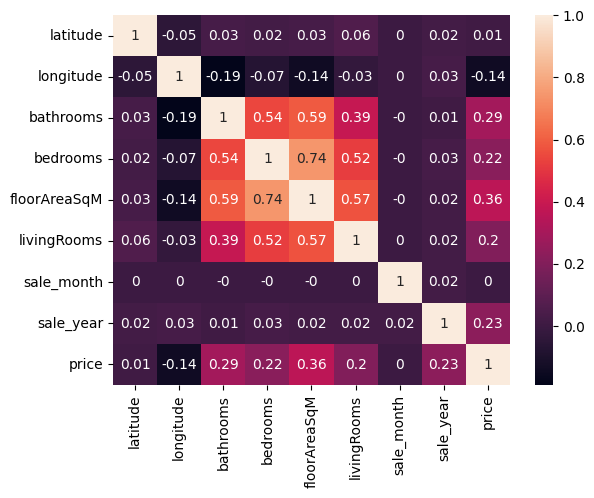

In [113]:
sns.heatmap(data[num_features].corr().round(2), annot=True)

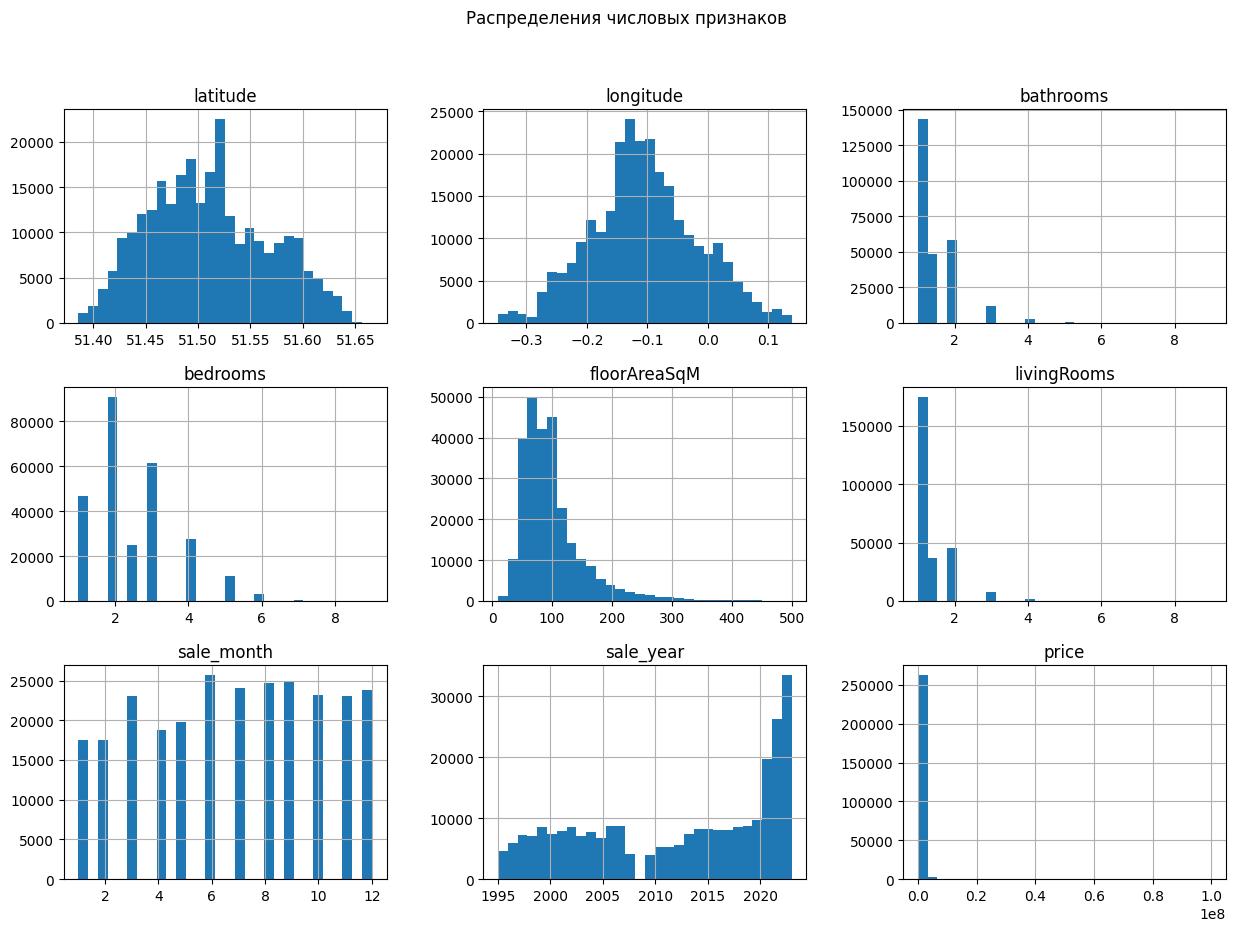

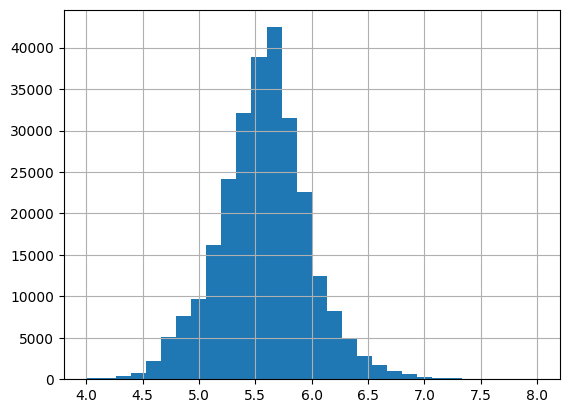

Корреляция с ценой:
 price           1.000000
floorAreaSqM    0.362137
bathrooms       0.286442
sale_year       0.225839
bedrooms        0.222507
livingRooms     0.203966
latitude        0.009192
sale_month      0.004694
longitude      -0.137680
Name: price, dtype: float64


In [114]:
data[num_features].hist(bins=30, figsize=(15, 10))
plt.suptitle('Распределения числовых признаков')
plt.show()


np.log10(data['price'] + 1).hist(bins = 30)
plt.show()


corr_with_price = data[num_features].corr()['price'].sort_values(ascending=False)
print("Корреляция с ценой:\n", corr_with_price)

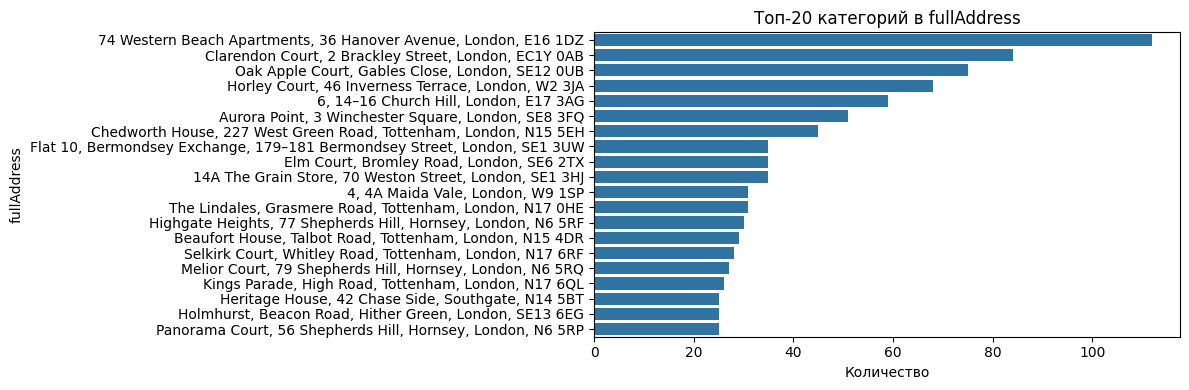

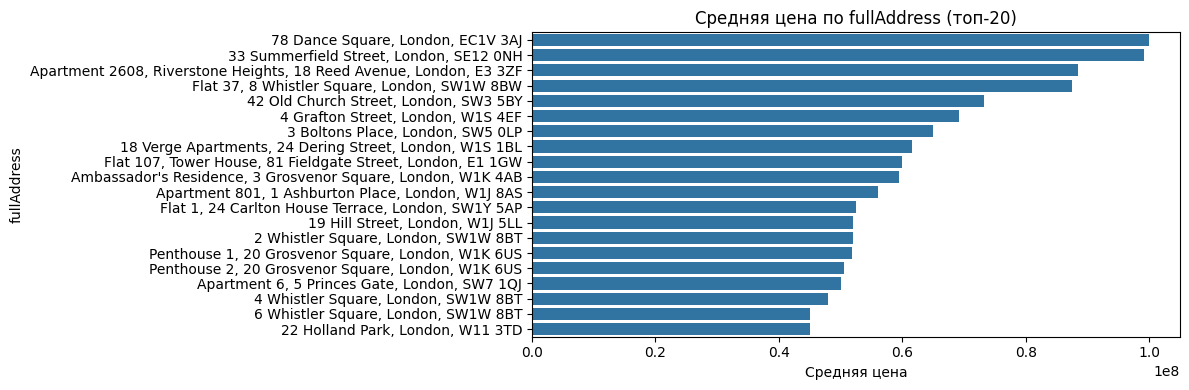

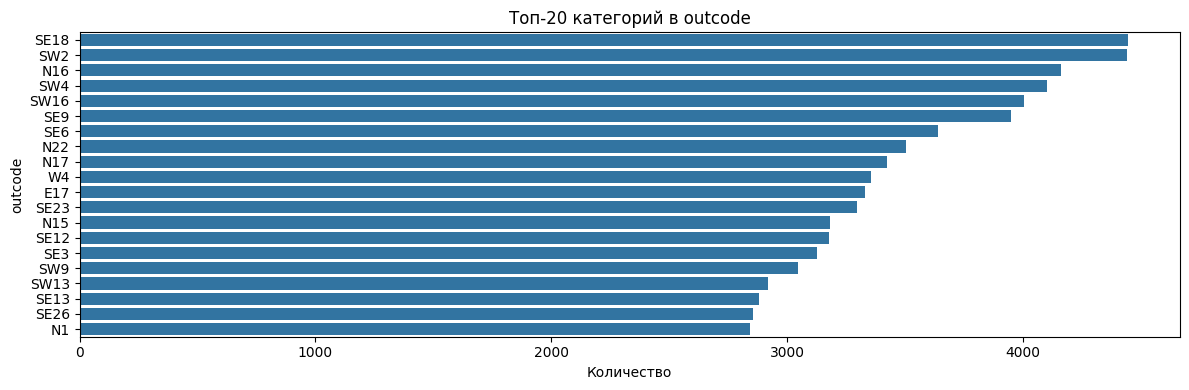

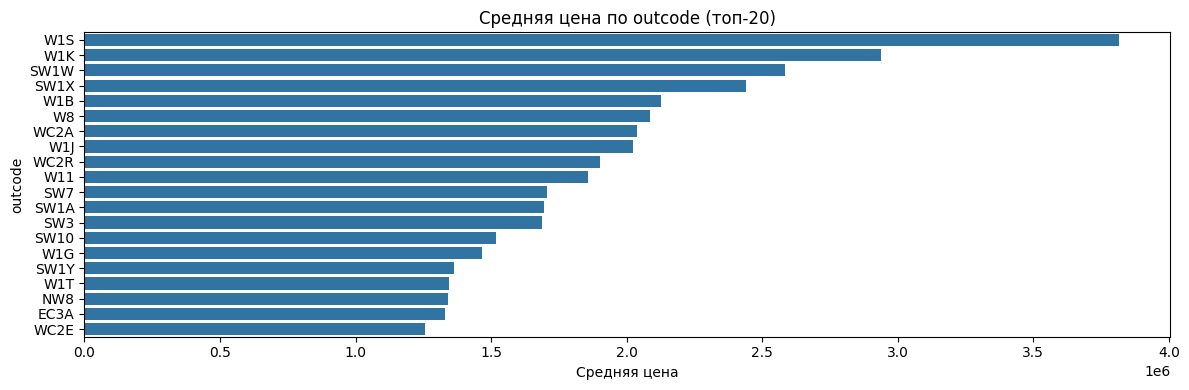

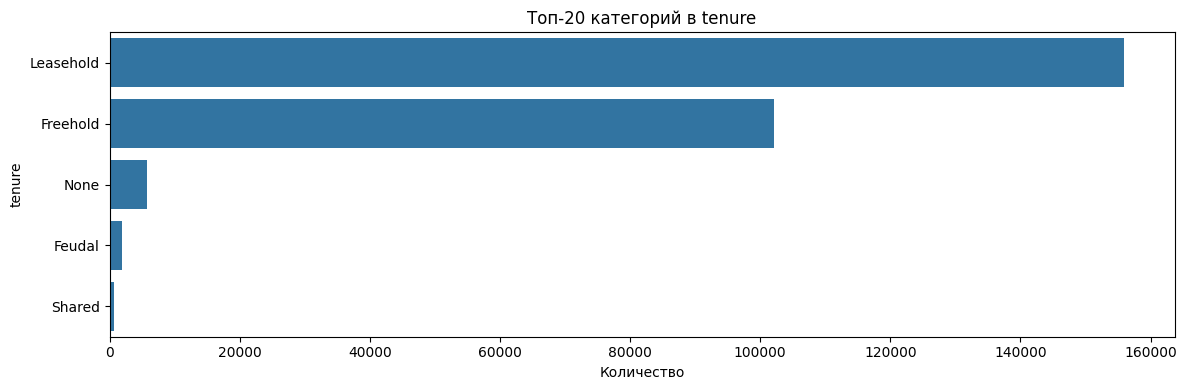

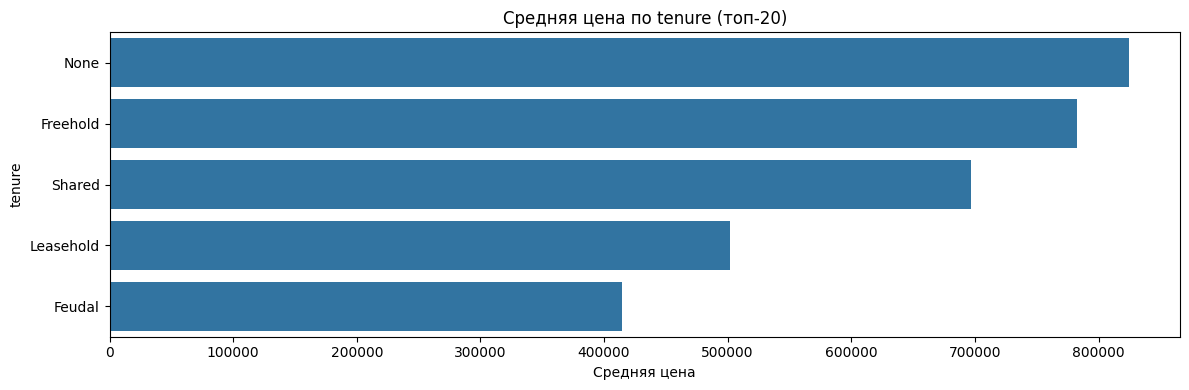

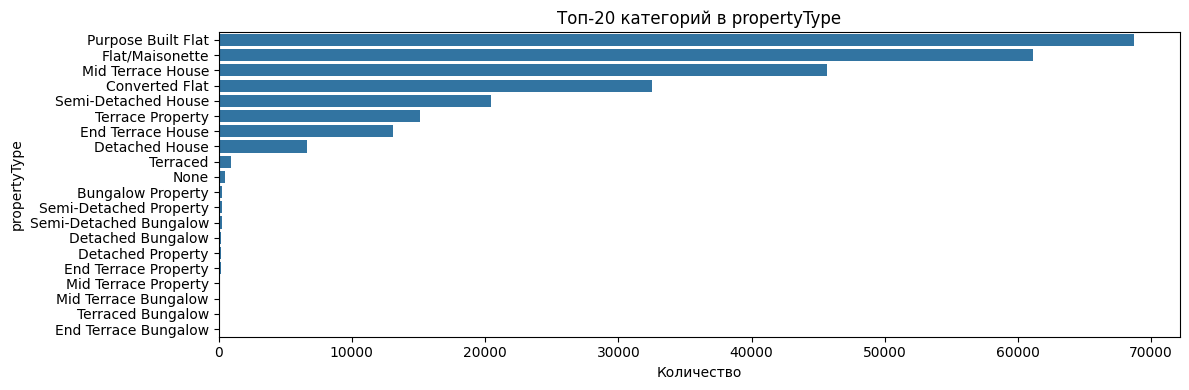

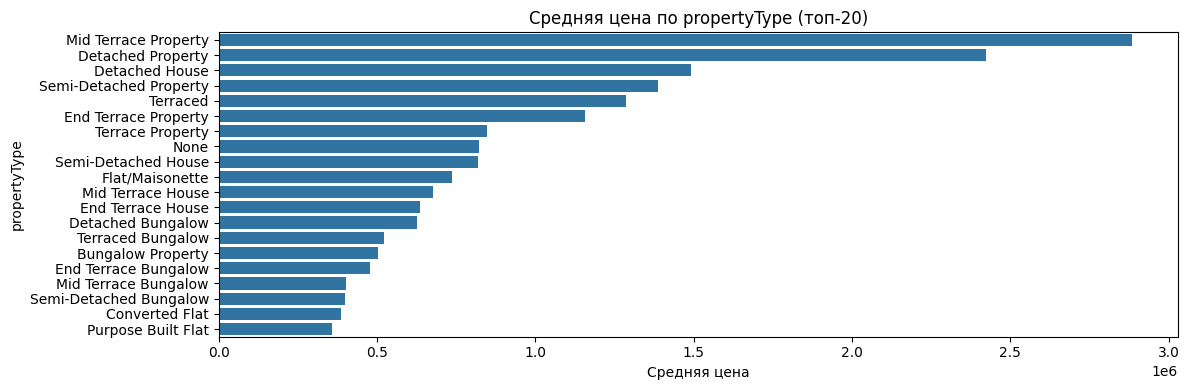

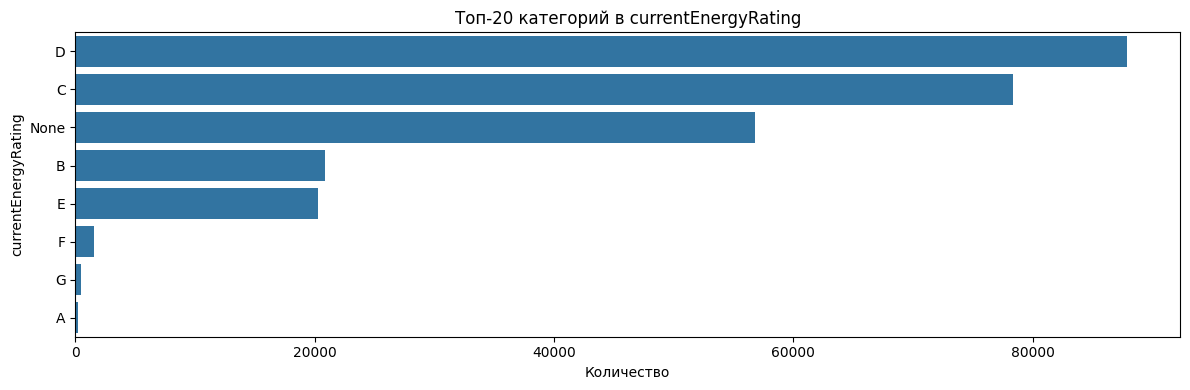

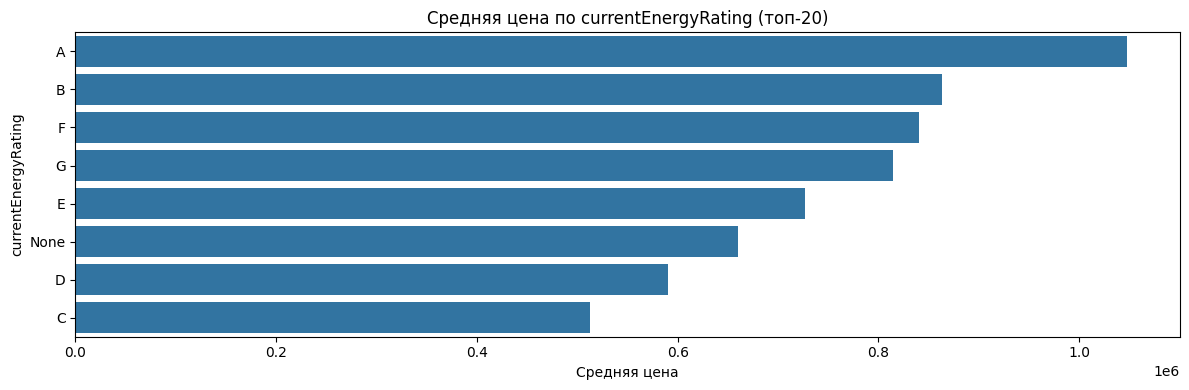

In [115]:
cat_cols = data.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    plt.figure(figsize=(12, 4))
    
    top_cats = data[col].value_counts().head(20)
    sns.barplot(x=top_cats.values, y=top_cats.index)
    plt.title(f'Топ-20 категорий в {col}')
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.show()
    
    mean_price = data.groupby(col)['price'].mean().sort_values(ascending=False).head(20)
    plt.figure(figsize=(12, 4))
    sns.barplot(x=mean_price.values, y=mean_price.index)
    plt.title(f'Средняя цена по {col} (топ-20)')
    plt.xlabel('Средняя цена')
    plt.tight_layout()
    plt.show()

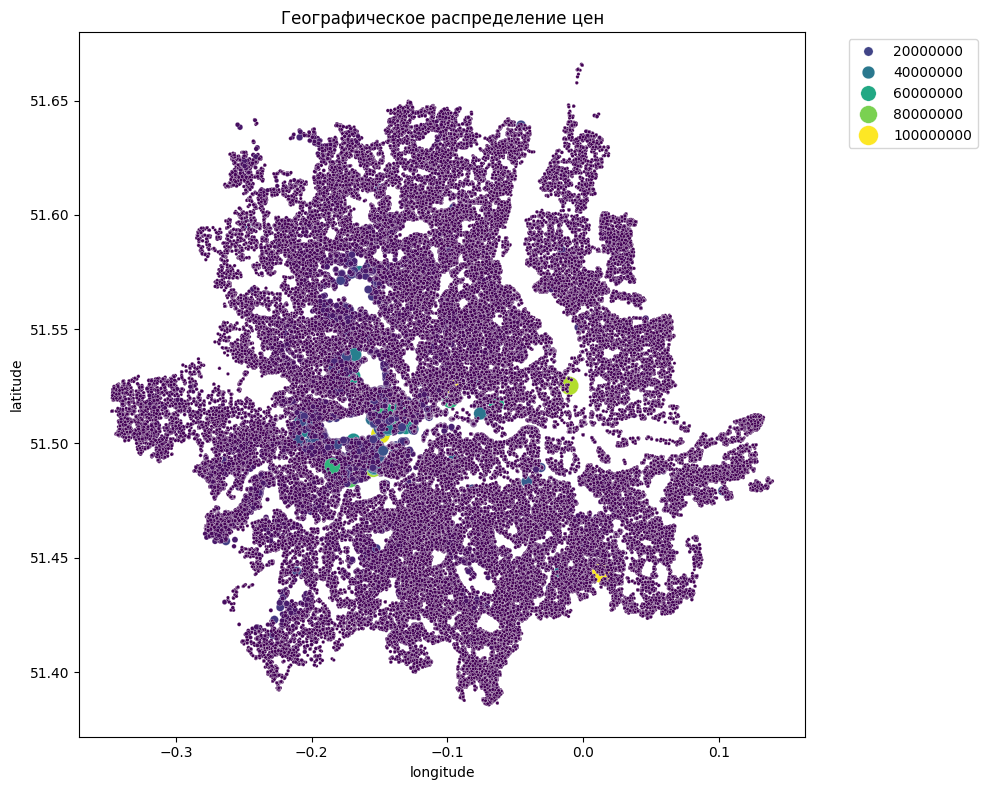

In [116]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='longitude', y='latitude', hue='price', palette='viridis', size='price', sizes=(5, 200))
plt.title('Географическое распределение цен')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [117]:
data['outcode_target'] = np.nan
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(data):
    train, val = data.iloc[train_idx], data.iloc[val_idx]
    means = train.groupby('outcode')['price'].mean()
    data.loc[val_idx, 'outcode_target'] = val['outcode'].map(means)
data['outcode_target'] = data['outcode_target'].fillna(data['price'].mean())

In [118]:
for col in cat_cols:
    print(col, len(data[col].unique()))

fullAddress 118345
outcode 167
tenure 5
propertyType 20
currentEnergyRating 8


In [119]:
cat_cols.remove('fullAddress')
cat_cols.remove('outcode')

In [120]:
OHE = OneHotEncoder()

In [121]:
encoded = OHE.fit_transform(data[cat_cols]).toarray()

In [122]:
encoded_df = pd.DataFrame(encoded, columns = OHE.get_feature_names_out())

In [123]:
data = pd.concat([data, encoded_df], axis = 1)

In [124]:
data.drop(columns = cat_cols, inplace = True)

In [125]:
data['fullAddress'].shape

(266325,)

In [126]:
model_name = "google-bert/bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float16).cuda()
model.eval()

n_samples = len(data)
embedding_dim = 768
dtype = np.float16

address_vectors = np.zeros((n_samples, embedding_dim), dtype=dtype)

batch_size = 256
sentences = data['fullAddress'].tolist()

for i in tqdm(range(0, n_samples, batch_size)):
    batch = sentences[i:i+batch_size]
    
    inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
    inputs = {k: v.cuda() for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    hidden = outputs.last_hidden_state
    
    mask = inputs['attention_mask'].unsqueeze(-1) 
    mean_pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)  
    
    batch_np = mean_pooled.cpu().numpy().astype(dtype)
    
    address_vectors[i:i+len(batch)] = batch_np
    
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1041/1041 [01:23<00:00, 12.54it/s]


In [127]:
len(address_vectors)

266325

In [128]:
addres_matrix = np.stack(address_vectors)

In [129]:
addres_matrix.shape

(266325, 768)

In [130]:
PCA = sklearn.decomposition.PCA(n_components=100)

In [131]:
Decomposed = PCA.fit_transform(addres_matrix)

In [132]:
Decomposed.shape

(266325, 100)

In [133]:
PCA.get_feature_names_out()

array(['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7',
       'pca8', 'pca9', 'pca10', 'pca11', 'pca12', 'pca13', 'pca14',
       'pca15', 'pca16', 'pca17', 'pca18', 'pca19', 'pca20', 'pca21',
       'pca22', 'pca23', 'pca24', 'pca25', 'pca26', 'pca27', 'pca28',
       'pca29', 'pca30', 'pca31', 'pca32', 'pca33', 'pca34', 'pca35',
       'pca36', 'pca37', 'pca38', 'pca39', 'pca40', 'pca41', 'pca42',
       'pca43', 'pca44', 'pca45', 'pca46', 'pca47', 'pca48', 'pca49',
       'pca50', 'pca51', 'pca52', 'pca53', 'pca54', 'pca55', 'pca56',
       'pca57', 'pca58', 'pca59', 'pca60', 'pca61', 'pca62', 'pca63',
       'pca64', 'pca65', 'pca66', 'pca67', 'pca68', 'pca69', 'pca70',
       'pca71', 'pca72', 'pca73', 'pca74', 'pca75', 'pca76', 'pca77',
       'pca78', 'pca79', 'pca80', 'pca81', 'pca82', 'pca83', 'pca84',
       'pca85', 'pca86', 'pca87', 'pca88', 'pca89', 'pca90', 'pca91',
       'pca92', 'pca93', 'pca94', 'pca95', 'pca96', 'pca97', 'pca98',
       'pca99'], dtyp

In [134]:
PCAed = pd.DataFrame(Decomposed,columns = PCA.get_feature_names_out())

In [135]:
PCAed

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca90,pca91,pca92,pca93,pca94,pca95,pca96,pca97,pca98,pca99
0,0.109932,-1.014191,0.881874,-0.766210,1.419010,0.030469,0.830042,-0.214113,0.718457,-0.264284,...,-0.037202,-0.269838,-0.035795,-0.026876,-0.085187,-0.004756,-0.225570,-0.083968,-0.160306,-0.004655
1,-1.575198,-2.107470,0.757907,-0.850563,0.965403,0.534921,-0.844169,-0.082717,0.481256,-0.392558,...,0.280649,-0.031974,0.005701,0.142487,0.125154,-0.079359,0.060558,0.205053,0.100214,-0.004876
2,-0.876657,1.092068,0.097745,-0.273077,0.603822,-0.435441,0.033521,-0.003923,0.587322,0.769875,...,-0.000891,0.386367,-0.135395,0.061399,-0.151772,0.352741,-0.024832,0.057852,-0.014658,-0.059264
3,-1.162072,-0.127344,-0.164787,1.091515,0.936906,-0.132349,-0.418906,0.326268,1.271888,-0.400586,...,0.018802,-0.133814,-0.015531,0.054097,-0.020259,-0.086504,-0.165891,-0.036723,0.115730,-0.036001
4,-1.299867,1.134234,-1.052375,-0.411384,-0.208589,0.312126,-0.316666,-0.022227,0.429742,0.098688,...,-0.087383,0.140271,-0.079941,-0.081052,0.037858,0.047698,-0.016526,-0.169736,0.109592,0.164497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266320,0.668313,-0.969282,-0.859945,-0.341566,0.277481,0.062270,-0.427485,-0.064201,-0.246622,0.750842,...,0.075154,-0.134080,0.048905,-0.017507,-0.034222,-0.092071,-0.158111,0.110353,-0.009597,0.083033
266321,-0.038140,-0.954615,0.715954,0.288450,-0.518617,0.856058,-1.644306,-0.782728,-0.053435,0.609978,...,-0.058042,0.022395,0.001949,0.203048,0.023198,0.062169,0.109263,0.185442,-0.088130,0.131347
266322,1.675627,0.086892,0.107453,0.201164,0.001473,0.060029,0.011830,0.083361,-0.197381,0.236914,...,-0.108877,0.007942,0.061255,-0.100288,0.109300,0.119490,-0.105171,-0.003874,0.198985,-0.043090
266323,1.160069,-0.826294,-0.913228,-0.019921,-0.776159,0.256787,0.737990,0.280932,-0.192877,0.849945,...,0.414675,0.026991,0.037831,0.023596,0.119022,0.035932,0.024498,0.014620,0.163599,0.093905


In [136]:
data.drop(columns = 'fullAddress', inplace = True)

In [137]:
data = pd.concat([data, PCAed], axis = 1)

In [138]:
X_train = data.drop(columns= ['outcode', 'price'])
y_train = np.log1p(data['price'])

In [139]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'tree_method': 'hist',
        'device': 'cuda',
        'nthread': 1,
    }

    n_estimators = trial.suggest_int('n_estimators', 200, 800)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        dtrain = xgb.DMatrix(X_tr, label=y_tr, nthread=1)
        dvalid = xgb.DMatrix(X_val, label=y_val, nthread=1)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=n_estimators,
            evals=[(dvalid, 'eval')],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        pred = model.predict(dvalid)
        scores.append(mean_squared_log_error(y_val, pred))

    return np.mean(scores)

In [140]:
study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20))
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=1)
best_params = study.best_params 
print(best_params)

[I 2026-02-24 22:18:10,322] A new study created in memory with name: no-name-365ecd66-3b84-45b6-b391-2c5031c3022a


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-24 22:18:30,933] Trial 0 finished with value: 0.000662128971304656 and parameters: {'max_depth': 6, 'learning_rate': 0.06600013746021474, 'subsample': 0.9548363839161931, 'colsample_bytree': 0.6244889099726704, 'min_child_weight': 2, 'gamma': 3.626394945773181, 'reg_alpha': 0.04212087988441275, 'reg_lambda': 5.5633082967329846e-05, 'n_estimators': 699}. Best is trial 0 with value: 0.000662128971304656.
[I 2026-02-24 22:18:46,549] Trial 1 finished with value: 0.0006778070764970699 and parameters: {'max_depth': 6, 'learning_rate': 0.12981491401767714, 'subsample': 0.8533547726204079, 'colsample_bytree': 0.6322812853334439, 'min_child_weight': 4, 'gamma': 4.625496294546025, 'reg_alpha': 0.077886096454695, 'reg_lambda': 0.3915287694813342, 'n_estimators': 307}. Best is trial 0 with value: 0.000662128971304656.
[I 2026-02-24 22:19:01,183] Trial 2 finished with value: 0.0006710830886023607 and parameters: {'max_depth': 8, 'learning_rate': 0.1945162161451821, 'subsample': 0.6678292

In [141]:
best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6966178985867442, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.004115053976502782, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.12762951161841468,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=749, n_jobs=None,
             num_parallel_tree=None, ...)

In [142]:
best_model.save_model("model.json")

In [143]:
y_pred = best_model.predict(X_train)

In [144]:
r2 = r2_score((y_train), (y_pred))
print(f"R^2: {r2}")

MAE = mean_absolute_error((y_train), (y_pred))
print(f"MAE: {MAE}")

R^2: 0.9472068927526571
MAE: 0.1358047387613034


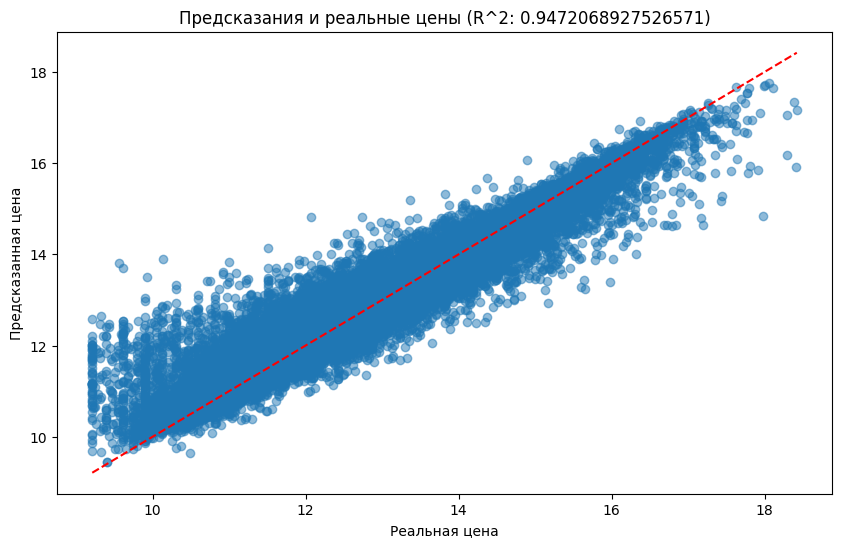

In [145]:
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Предсказания и реальные цены (R^2: {r2})')
plt.show()

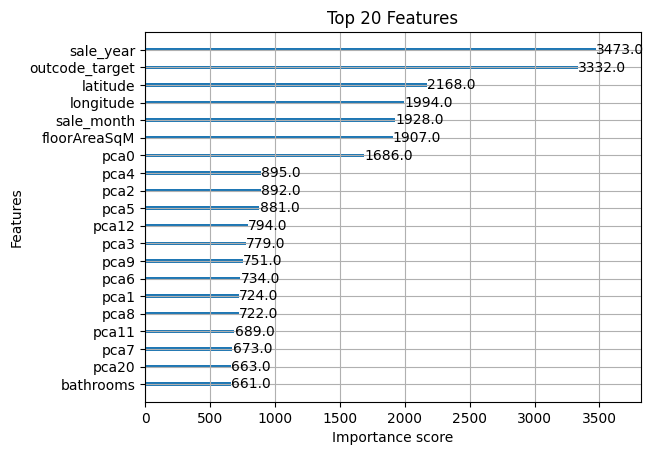

In [146]:
xgb.plot_importance(best_model, max_num_features=20)
plt.title('Top 20 Features')
plt.show()

In [149]:
best_model.save_model('best_london_house_xgboost.json')

# Сабмит на kaggle 

In [147]:
test_data = pd.read_csv('/kaggle/input/competitions/london-house-price-prediction-advanced-techniques/test.csv')



test_data.drop(columns = 'country', inplace = True)
test_data.drop(columns = 'postcode', inplace = True)
test_data.drop(columns = 'ID', inplace = True)



outcode_means = data.groupby('outcode')['price'].mean()  

test_data['outcode_target'] = test_data['outcode'].map(outcode_means)

test_data['outcode_target'] = test_data['outcode_target'].fillna(data['price'].mean())




for col in test_data.columns:
    if (test_data[col].dtype == 'O'):
        test_data[col] = test_data[col].fillna('None')
    else:
        test_data[col] = test_data[col].fillna(test_data[col].mean())





n_samples_test = len(test_data)
embedding_dim = 768
dtype = np.float16
batch_size = 256    

encoded_test = OHE.transform(test_data[cat_cols]).toarray()
encoded_test_df = pd.DataFrame(encoded_test, columns=OHE.get_feature_names_out())

test_data_processed = test_data.drop(columns=cat_cols).copy()
test_data_processed = pd.concat([test_data_processed, encoded_test_df], axis=1)

address_vectors_test = np.zeros((n_samples_test, embedding_dim), dtype=dtype)
sentences_test = test_data['fullAddress'].tolist()

for i in tqdm(range(0, n_samples_test, batch_size)):
    batch = sentences_test[i:i+batch_size]
    
    inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
    inputs = {k: v.cuda() for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    hidden = outputs.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1)               
    mean_pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1) 
    
    batch_np = mean_pooled.cpu().numpy().astype(dtype)
    address_vectors_test[i:i+len(batch)] = batch_np
    
    torch.cuda.empty_cache()

decomposed_test = PCA.transform(address_vectors_test)  
pca_test_df = pd.DataFrame(decomposed_test, columns=PCA.get_feature_names_out())




test_data_processed.drop(columns='fullAddress', inplace=True)
test_data_final = pd.concat([test_data_processed, pca_test_df], axis=1)



Test_prediction = np.expm1(best_model.predict(test_data_final.drop(columns='outcode')))

predseries = pd.Series(Test_prediction)

submit = pd.read_csv('/kaggle/input/competitions/london-house-price-prediction-advanced-techniques/sample_submission.csv')


submit['price'] = predseries


submit.to_csv('submission.csv', index = False)

100%|██████████| 65/65 [00:05<00:00, 12.80it/s]
